# Clasificación y predicción de respuesta a tratamiento de tumores cerebrales

Este proyecto tiene como finalidad, clasificar y predecir la respuesta a un tratamiento de una persona con algun tipo de tumor cerebral a partir de datos clinicos, información del paciente y resultados del tratamiento.


La razon de este proyecto es porque a lo largo de los años, el porcentaje de personas con tumores cerebrales ha aumentado significativamente. Segun articulos cientificos, aproximadamente `1.3 millones` de personas en los estados unidos viven con algun tipo de tumor cerebra, de los cuales solo `108,810`, es decir casi solo el `12%` de ellos, recibe algun diagnostico al respecto y solo el `34.8 %` de esas personas dianosticadas sobreviven.

> Brain Tumor Facts - National Brain Tumor Society. (2026, 6 marzo). National Brain Tumor Society. https://braintumor.org/brain-tumors/about-brain-tumors/brain-tumor-facts/



De modo que el entender el comportamiento  y el como los pacientes reaccionan al tratamiento de estos tumores, es una gran ayuda a las organizaciones que se dedican a estudiar el tema, combinado con la inteligencia artificial y el machine learning, nos da un alcance bastante amplio para poder abordar este tema.

Dataset obtenido de kaggke *"Brain Tumor Risk & Treatment Dataset
A Comprehensive Dataset for Tumor Classification and Treatment Study"*

Dataset: https://www.kaggle.com/datasets/algozee/brain-tumor-risk-and-treatment-dataset

Exploración y comprension del conjunto de datos

Con el fin de entender la naturaleza del dataset, vamos a cargar los datos que tengamos y entender las variables que lo conforman.

>Nota: el dataset viene compuesto de 3 archivos csv, los cuales son:
- Patient_info (informacion del paciente)
- Tratment_outcome (Resultado del tratamiento)
- Tumor_clinical_data (Datos clinicos)

Sabiendo esto, para manejar los datos de forma mas sencilla, tendremos que hacer un merge, donde juntemos estos 3 archivos haciendolos coincidir por medio de una variable de ID.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# cargar datos y juntar datasets en un solo dataframe

import pandas as pd

# ── Carga de archivos ──────────────────────────────────────────────
patient_info     = pd.read_csv("/content/drive/MyDrive/Inteligencia_Artificial_1/Proyecto 2/Patient_Info.csv")
clinical_data    = pd.read_csv("/content/drive/MyDrive/Inteligencia_Artificial_1/Proyecto 2/Tumor_Clinical_Data.csv")
treatment_outcome = pd.read_csv("/content/drive/MyDrive/Inteligencia_Artificial_1/Proyecto 2/Treatment_Outcome.csv")

# ── Merge de los tres archivos usando Patient_ID como llave ────────
df = patient_info \
    .merge(clinical_data,      on="Patient_ID", how="inner") \
    .merge(treatment_outcome,  on="Patient_ID", how="inner")

# ── Verificación ───────────────────────────────────────────────────
print(f"✅ Filas:   {df.shape[0]}")
print(f"✅ Columnas: {df.shape[1]}")
print(f"\n📋 Columnas del dataset unificado:\n{list(df.columns)}")
df.head()


✅ Filas:   200
✅ Columnas: 30

📋 Columnas del dataset unificado:
['Patient_ID', 'Age', 'Gender', 'Tumor_Type', 'Tumor_Size_mm', 'Tumor_Location', 'Tumor_Grade', 'Headache', 'Seizures', 'Vision_Problems', 'Nausea', 'Cognitive_Changes', 'MRI_Intensity_Mean', 'MRI_Texture_Feature', 'Edema_Presence', 'Contrast_Enhancement', 'Family_History', 'Smoking_Status', 'Radiation_Exposure', 'Genetic_Risk', 'Treatment_Type', 'Surgery_Performed', 'Chemotherapy', 'Radiation_Therapy', 'Survival_Months', 'Tumor_Progression', 'Recurrence', 'Outcome_Status', 'Early_Detection_Label', 'Treatment_Response']


,Patient_ID,Age,Gender,Tumor_Type,Tumor_Size_mm,Tumor_Location,Tumor_Grade,Headache,Seizures,Vision_Problems,...,Treatment_Type,Surgery_Performed,Chemotherapy,Radiation_Therapy,Survival_Months,Tumor_Progression,Recurrence,Outcome_Status,Early_Detection_Label,Treatment_Response
0,1,61,Male,Meningioma,8.07,Temporal,I,1,0,0,...,Radiation,0,0,1,64,0,1,Recovered,1,Poor
1,2,24,Female,Meningioma,45.54,Occipital,IV,1,1,1,...,Chemotherapy,0,1,1,95,0,0,Critical,0,Good
2,3,70,Male,Meningioma,35.03,Temporal,III,0,0,1,...,Radiation,1,0,1,67,1,0,Recovered,0,Poor
3,4,30,Female,Meningioma,43.82,Frontal,I,1,1,0,...,Radiation,1,1,1,81,1,0,Critical,0,Moderate
4,5,33,Female,Glioma,58.28,Temporal,I,0,1,0,...,Surgery,0,1,0,16,0,1,Stable,1,Good


Listo!, ya tenemos nuestro dataset unificado en el dataframe `df`, ahora si vamos a comprender un poco del contexto de los datos.

# Glosario de variables

---

## 1. Información del Paciente

| Variable | Tipo | Valores Posibles | Descripción |
|---|---|---|---|
| `Patient_ID` | Entero | ID único (ej. 1, 2, 3...) | Identificador único de cada paciente. Sirve como llave primaria para unir los tres archivos. |
| `Age` | Entero | Rango numérico (ej. 12 – 70+) | Edad del paciente en años al momento del diagnóstico. |
| `Gender` | Categórico | `Male`, `Female` | Género biológico del paciente. |

---

## 2. Datos Clínicos del Tumor

### Características del Tumor

| Variable | Tipo | Valores Posibles | Descripción |
|---|---|---|---|
| `Tumor_Type` | Categórico | `Glioma`, `Meningioma`, `Pituitary` | Tipo histológico del tumor cerebral diagnosticado. |
| `Tumor_Size_mm` | Decimal | Rango continuo (ej. 8.07 – 58.28) | Tamaño del tumor medido en milímetros. |
| `Tumor_Location` | Categórico | `Frontal`, `Temporal`, `Parietal`, `Occipital` | Región del cerebro donde se localiza el tumor. |
| `Tumor_Grade` | Ordinal | `I`, `II`, `III`, `IV` | Grado de malignidad del tumor según clasificación de la OMS. El grado IV es el más agresivo. |

### Síntomas Clínicos
> Las siguientes variables son **binarias**: `1 = Presente`, `0 = Ausente`

| Variable | Tipo | Valores Posibles | Descripción |
|---|---|---|---|
| `Headache` | Binario | `0`, `1` | Indica si el paciente presenta dolores de cabeza frecuentes o severos. |
| `Seizures` | Binario | `0`, `1` | Indica si el paciente ha presentado convulsiones. |
| `Vision_Problems` | Binario | `0`, `1` | Indica si el paciente reporta problemas de visión relacionados al tumor. |
| `Nausea` | Binario | `0`, `1` | Indica la presencia de náuseas como síntoma asociado. |
| `Cognitive_Changes` | Binario | `0`, `1` | Indica cambios cognitivos como pérdida de memoria, confusión o dificultad para concentrarse. |

### Características de Imagen (MRI)

| Variable | Tipo | Valores Posibles | Descripción |
|---|---|---|---|
| `MRI_Intensity_Mean` | Decimal | 0.0 – 1.0 | Intensidad promedio de la señal en la imagen de resonancia magnética. Valores más altos pueden indicar mayor actividad tumoral. |
| `MRI_Texture_Feature` | Decimal | 0.0 – 1.0 | Característica de textura extraída del MRI. Representa la heterogeneidad del tejido tumoral. |
| `Edema_Presence` | Binario | `0`, `1` | Indica si se observa edema (inflamación) alrededor del tumor en la imagen. |
| `Contrast_Enhancement` | Binario | `0`, `1` | Indica si el tumor muestra realce con contraste en el MRI, lo cual sugiere mayor agresividad. |

### Factores de Riesgo

| Variable | Tipo | Valores Posibles | Descripción |
|---|---|---|---|
| `Family_History` | Binario | `0`, `1` | Indica si existe historial familiar de tumores cerebrales. |
| `Smoking_Status` | Categórico | `Yes`, `No` | Indica si el paciente es o fue fumador. |
| `Radiation_Exposure` | Binario | `0`, `1` | Indica si el paciente tuvo exposición previa a radiación ionizante. |
| `Genetic_Risk` | Ordinal | `Low`, `Medium`, `High` | Nivel de riesgo genético estimado para desarrollar tumor cerebral. |

---

## 3. Resultado del Tratamiento

### Tipo de Tratamiento Aplicado

| Variable | Tipo | Valores Posibles | Descripción |
|---|---|---|---|
| `Treatment_Type` | Categórico | `Surgery`, `Chemotherapy`, `Radiation` | Tipo principal de tratamiento que recibió el paciente. |
| `Surgery_Performed` | Binario | `0`, `1` | Indica si se realizó una intervención quirúrgica. |
| `Chemotherapy` | Binario | `0`, `1` | Indica si el paciente recibió quimioterapia. |
| `Radiation_Therapy` | Binario | `0`, `1` | Indica si el paciente recibió radioterapia. |

### Evolución y Pronóstico

| Variable | Tipo | Valores Posibles | Descripción |
|---|---|---|---|
| `Survival_Months` | Entero | Rango numérico (ej. 16 – 106) | Número de meses de supervivencia del paciente desde el diagnóstico. |
| `Tumor_Progression` | Binario | `0`, `1` | Indica si el tumor mostró progresión (crecimiento o avance) durante o después del tratamiento. |
| `Recurrence` | Binario | `0`, `1` | Indica si el tumor reapareció después de haber sido tratado. |
| `Early_Detection_Label` | Binario | `0`, `1` | Indica si el tumor fue detectado en una etapa temprana (`1`) o tardía (`0`). |

### Variables Objetivo (Target)

> Estas son las variables más relevantes para construir el modelo de clasificación.

| Variable | Tipo | Valores Posibles | Descripción |
|---|---|---|---|
| `Outcome_Status` | Categórico  | `Recovered`, `Stable`, `Critical` | **Variable objetivo principal.** Estatus final de recuperación del paciente tras el tratamiento. |
| `Treatment_Response` | Categórico | `Good`, `Moderate`, `Poor` | Nivel de respuesta del paciente al tratamiento recibido. Puede usarse como variable objetivo alternativa. |

---

# Preparación y tratamiento de los datos



Con el fin de que el dataset este listo para trabajar, buscaremos hacer cierta limpieza, transformación de variables, busqueda de datos atipicos, datos faltantes, para poder tratarlos de forma correspondiente y asi trabajar un buen dataset.

>Nota: la base de datos fue descargada de kaggle, como podemos ver algunas variables ya son binarias, eso facilita el trabajo, a simple vista parece que no hay valores faltantes, pero de igual forma eso se verificara.

## Transformación de variables

Recordemos que algunas variables son cualitativas (categoricas), las cuales no podemos trabajar, asi que para eso las convertiremos a binarias.

### Genero

Convertiremos la variable de genero donde 1= Mujer y 0=Hombre, esto para poder tener un dato numerico con el que podamos trabajar en vez de tener un dato categorico.

In [ ]:

# Convertir Gender a variable binaria (1 = Female, 0 = Male)
df['Gender'] = df['Gender'].map({'Female': 1, 'Male': 0})

# Verificación
print(df['Gender'].value_counts())
print(f"\nTipo de dato: {df['Gender'].dtype}")

Gender
1    107
0     93
Name: count, dtype: int64

Tipo de dato: int64


Vemos que tenemos 107 mujeres y 93 hombres en el dataset ya nuevo con la variable binaria.

Ahora, del mismo modo utilizemos one-hot-encoding para convertir a binario la variable de `Tumor_type`, donde tendremos 3 columnas derivadas de esa donde tendra la siguient logica 1= presente, 0= ausente.

In [ ]:
# One-Hot Encoding con valores 0 y 1 (enteros)
df = pd.get_dummies(df, columns=['Tumor_Type'], prefix='Tumor').astype({
    'Tumor_Glioma': int,
    'Tumor_Meningioma': int,
    'Tumor_Pituitary': int
})

# Verificación
print(df[['Tumor_Glioma', 'Tumor_Meningioma', 'Tumor_Pituitary']].head(10))
print(f"\nTipo de datos:\n{df[['Tumor_Glioma', 'Tumor_Meningioma', 'Tumor_Pituitary']].dtypes}")

   Tumor_Glioma  Tumor_Meningioma  Tumor_Pituitary
0             0                 1                0
1             0                 1                0
2             0                 1                0
3             0                 1                0
4             1                 0                0
5             0                 1                0
6             0                 1                0
7             0                 0                1
8             0                 1                0
9             0                 0                1

Tipo de datos:
Tumor_Glioma        int64
Tumor_Meningioma    int64
Tumor_Pituitary     int64
dtype: object


Listo!, ahora vemos que la variable `Tumor_type` ya no esta, en su lugar, hay otras 3 variables donde se describe si ese tipo de tumor esta presente, es cierto que ahora generamos mas variables con las cuales trabajar, pero, ahora podemos tratarlas de forma mas sencilla

### Localización del Tumor

Tenemos una variable llamada `Tumor_location`, la cual nos describe la ubicacion del tumor en el cerebro, a esta tambien le aplicaremos el metodo de One-hot-encoding, para generar distintas variables a partir de sus clases.

In [ ]:
# One-Hot Encoding para Tumor_Location con valores 0 y 1
df = pd.get_dummies(df, columns=['Tumor_Location'], prefix='Location')
df = df.apply(lambda col: col.astype(int) if col.dtype == bool else col)

# Verificación
location_cols = ['Location_Frontal', 'Location_Occipital', 'Location_Parietal', 'Location_Temporal']
print(df[location_cols].head(10))
print(f"\nTipo de datos:\n{df[location_cols].dtypes}")

   Location_Frontal  Location_Occipital  Location_Parietal  Location_Temporal
0                 0                   0                  0                  1
1                 0                   1                  0                  0
2                 0                   0                  0                  1
3                 1                   0                  0                  0
4                 0                   0                  0                  1
5                 0                   0                  0                  1
6                 0                   0                  1                  0
7                 0                   1                  0                  0
8                 0                   0                  1                  0
9                 0                   0                  1                  0

Tipo de datos:
Location_Frontal      int64
Location_Occipital    int64
Location_Parietal     int64
Location_Temporal     int64
dtype: object


Perfecto!, ahora tenemos 4 variables que nos describen la ubicación del tumor, asi mismo, la varible `Tumor_location`, ha desaparecido.

## Otras variables

Siguiendo esta misma lógica, haremos el mismo proceso a las variables de:
- `Tumor_Grade`
- `Genetic_Risk`
- `Treatment_Type`
- `Smoking_Status`

Con la consideración de que excluiremos ciertas variables como:
- `Patient_ID`
- `Outcome_Status`
- `Treatment_Response`

Esto ya que el ID no nos sirve para analizar, pues solo es un identificador.
En cuanto a `Treatment_Response`, es nuestra **variable objetivo**, por lo que
la guardaremos por separado antes de cualquier transformación.

Finalmente, `Outcome_Status` también se excluye ya que es otra variable de salida
y podría estar correlacionada con `Treatment_Response`, lo que causaría
**fuga de datos** si se incluyera como feature.

Por lo tanto, guardaremos `Treatment_Response` en la variable `y`, y el resto
de las features en un nuevo dataframe llamado `df_features`.

In [ ]:
# PASO 1 — Guardar y quitar objetivos
y = df['Treatment_Response']
df_features = df.drop(columns=['Patient_ID', 'Outcome_Status', 'Treatment_Response'])

# PASO 2 — Convertir Smoking_Status a binaria
df_features['Smoking_Status'] = df_features['Smoking_Status'].map({'Yes': 1, 'No': 0})

# PASO 3 — One-Hot Encoding solo a features
variables_categoricas = ['Tumor_Grade', 'Genetic_Risk', 'Treatment_Type']
prefijos              = ['Grade',        'Risk',          'Treatment']

df_features = pd.get_dummies(df_features, columns=variables_categoricas, prefix=prefijos)
df_features = df_features.apply(lambda col: col.astype(int) if col.dtype == bool else col)

# ── Verificación — mostrar columnas generadas por el One-Hot Encoding ──
print("✅ Columnas generadas por One-Hot Encoding:\n")
for prefijo in prefijos:
    cols = [col for col in df_features.columns if col.startswith(prefijo)]
    print(f"  {variables_categoricas[prefijos.index(prefijo)]}:")
    for col in cols:
        print(f"    → {col}")

✅ Columnas generadas por One-Hot Encoding:

  Tumor_Grade:
    → Grade_I
    → Grade_II
    → Grade_III
    → Grade_IV
  Genetic_Risk:
    → Risk_High
    → Risk_Low
    → Risk_Medium
  Treatment_Type:
    → Treatment_Chemotherapy
    → Treatment_Radiation
    → Treatment_Surgery


Bien, ya tenemos nuestras variables convertidas a binarias, el siguiente paso es buscar valores atipicos y valores faltantes, en caso de que existan, los trataremos de forma correspondiente.

### Datos Faltantes

Busquemos si es que hay huecos en el dataset, verifiquemos si faltan datos por columna.

In [ ]:
# ── Verificación de valores faltantes ─────────────────────────────
missing = df_features.isnull().sum()
missing_pct = (missing / len(df_features)) * 100

# Crear tabla resumen
missing_df = pd.DataFrame({
    'Valores Faltantes': missing,
    'Porcentaje (%)':    missing_pct.round(2)
}).sort_values('Porcentaje (%)', ascending=False)

# Mostrar solo columnas con al menos 1 faltante
faltantes = missing_df[missing_df['Valores Faltantes'] > 0]

if faltantes.empty:
    print(" No hay valores faltantes en el dataset.")
else:
    print(f"⚠️ Se encontraron valores faltantes en {len(faltantes)} columnas:\n")
    print(faltantes.to_string())

 No hay valores faltantes en el dataset.


Excelente, no hay valores faltantes, esto puede deberse a que el dataset se rescato de `kaggle`, donde seguramente la persona que publico el conjunto de datos ya habia echo ciertos cambios al dataset, posiblemente hasta quito datos atipicos o relleno con algun metodo de imputación, de cualquier forma, es bueno verificar. Ahora pasemos a ver si hay datos atipicos.

### Outliers

Ahora, verifiquemos si hay datos atipicos, esto lo haremos con el metodo de tukey, donde definiremos un rango intercuartil de datos Q1-Q3, donde los datos que caigan fuera de este rango, seran considerados atipicos.

In [ ]:
# ── Detección de Outliers con método de Tukey (IQR) ───────────────

# Solo aplicar a columnas numéricas continuas
cols_numericas = df_features.select_dtypes(include=['float64', 'int64']).columns

# Excluir columnas binarias (solo tienen 0 y 1, no tiene sentido buscar outliers)
cols_binarias  = [col for col in cols_numericas if df_features[col].nunique() == 2]
cols_continuas = [col for col in cols_numericas if col not in cols_binarias]

print(f"📋 Columnas analizadas ({len(cols_continuas)}): {cols_continuas}\n")

# ── Calcular outliers por columna ──────────────────────────────────
resultados = []
outlier_mask = pd.Series(False, index=df_features.index)  # Para % del dataset

for col in cols_continuas:
    Q1  = df_features[col].quantile(0.25)
    Q3  = df_features[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    es_outlier = (df_features[col] < limite_inferior) | (df_features[col] > limite_superior)
    outlier_mask = outlier_mask | es_outlier  # Acumular filas con al menos un outlier

    n_outliers = es_outlier.sum()
    pct_col    = (n_outliers / len(df_features)) * 100

    resultados.append({
        'Columna':            col,
        'Q1':                 round(Q1, 3),
        'Q3':                 round(Q3, 3),
        'IQR':                round(IQR, 3),
        'Límite Inferior':    round(limite_inferior, 3),
        'Límite Superior':    round(limite_superior, 3),
        'Outliers':           n_outliers,
        '% por Columna':      round(pct_col, 2)
    })

# ── Resultados por columna ─────────────────────────────────────────
resultados_df = pd.DataFrame(resultados).sort_values('% por Columna', ascending=False)
print("📊 Outliers por columna:")
print(resultados_df.to_string(index=False))

# ── Porcentaje del dataset ─────────────────────────────────────────
filas_con_outlier = outlier_mask.sum()
pct_dataset       = (filas_con_outlier / len(df_features)) * 100

print(f"\n📐 Filas con al menos un outlier: {filas_con_outlier} de {len(df_features)}")
print(f"📐 Porcentaje del dataset afectado: {pct_dataset:.2f}%")

📋 Columnas analizadas (5): ['Age', 'Tumor_Size_mm', 'MRI_Intensity_Mean', 'MRI_Texture_Feature', 'Survival_Months']

📊 Outliers por columna:
            Columna     Q1     Q3    IQR  Límite Inferior  Límite Superior  Outliers  % por Columna
                Age 24.000 63.000 39.000          -34.500          121.500         0            0.0
      Tumor_Size_mm 19.742 45.795 26.053          -19.336           84.874         0            0.0
 MRI_Intensity_Mean  0.394  0.681  0.287           -0.036            1.110         0            0.0
MRI_Texture_Feature  0.318  0.728  0.410           -0.297            1.343         0            0.0
    Survival_Months 33.750 96.250 62.500          -60.000          190.000         0            0.0

📐 Filas con al menos un outlier: 0 de 200
📐 Porcentaje del dataset afectado: 0.00%


Buena noticia, parece que no hay outliers, como lo sospechabamos, el autor del dataset se tomo la molestia de limpiar y preparar de forma parcial los datos, de cualquier modo, es bueno verificar.

### Split Train y Test

Ahora, partiremos los datos de trai y test en una proporcion de 80/20 respectivamente, usando stratify para asegurar el balance de las clases.

In [ ]:
from sklearn.model_selection import train_test_split

# ── Partición de datos 50/50 con stratify ─────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    df_features, y,
    test_size    = 0.2,   # 50% train, 50% test
    random_state = 42,
    stratify     = y      # Asegura proporciones iguales de cada clase
)

# ── Verificación ───────────────────────────────────────────────────
print(f"✅ X_train: {X_train.shape}")
print(f"✅ X_test:  {X_test.shape}")
print(f"✅ y_train: {y_train.shape}")
print(f"✅ y_test:  {y_test.shape}")

# ── Distribución de clases por partición ──────────────────────────
print(f"\n📊 Distribución en y_train:")
print(y_train.value_counts(normalize=True).mul(100).round(2).astype(str) + ' %')

print(f"\n📊 Distribución en y_test:")
print(y_test.value_counts(normalize=True).mul(100).round(2).astype(str) + ' %')

✅ X_train: (160, 39)
✅ X_test:  (40, 39)
✅ y_train: (160,)
✅ y_test:  (40,)

📊 Distribución en y_train:
Treatment_Response
Poor        36.88 %
Moderate     32.5 %
Good        30.63 %
Name: proportion, dtype: object

📊 Distribución en y_test:
Treatment_Response
Poor        37.5 %
Moderate    32.5 %
Good        30.0 %
Name: proportion, dtype: object


# Modelos de Clasificación

Ahora, sabiendo que la base de datos `df_features`, esta lista para trabajarse, crearemos multiples modelos para comparar y ver cual nos da mejores resultados en la clasificación y predicción de `Treatment_response` y `Outcome_status`

---

## Modelo de regresión logistica


La regresión logística es un modelo de clasificación que estima la **probabilidad**
de que una observación pertenezca a una clase. A diferencia de la regresión lineal,
su salida pasa por la **función sigmoide**, la cual transforma cualquier valor real
en un rango entre 0 y 1:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Donde $z$ es la combinación lineal de las variables del modelo (igual que en regresión lineal):

$$z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n$$

Como nuestro problema tiene **3 clases** (`Good`, `Moderate`, `Poor`),
se utiliza la extensión **Multinomial**, la cual en lugar de una sola función sigmoide,
aplica **Softmax** para calcular la probabilidad de cada clase simultáneamente,
asignando la clase con mayor probabilidad como predicción final.

$$P(y = k \mid x) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

---

## ¿Por qué normalizar?

Las variables numéricas del dataset como `Age`, `Tumor_Size_mm` o `Survival_Months`
tienen **escalas muy distintas**. Sin normalización, el modelo le daría más peso
a variables con valores grandes, sesgando los coeficientes $\beta$.

Con **StandardScaler** transformamos cada variable para que tenga:
- **Media = 0**
- **Desviación estándar = 1**

$$x' = \frac{x - \mu}{\sigma}$$

Esto asegura que todas las variables **compitan en igualdad de condiciones**
durante el entrenamiento.

### Normalizar datos

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Normalización ───────────────────────────────────────────────
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform en train
X_test_scaled  = scaler.transform(X_test)        # solo transform en test


### Crear modelo

In [ ]:
# ── 2. Modelo ──────────────────────────────────────────────────────
modelo_lr = LogisticRegression(
    multi_class  = 'multinomial',
    solver       = 'lbfgs',
    max_iter     = 1000,
    random_state = 42
)

modelo_lr.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42)

### Predicciones y metricas de desempeño

In [ ]:
# ── 3. Predicciones ────────────────────────────────────────────────
y_pred = modelo_lr.predict(X_test_scaled)

# ── 4. Métricas ────────────────────────────────────────────────────
accuracy = accuracy_score(y_test, y_pred)
print(f" Accuracy: {accuracy*100:.2f}%\n")
print(" Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

 Accuracy: 40.00%

 Reporte de Clasificación:
              precision    recall  f1-score   support

        Good       0.17      0.08      0.11        12
    Moderate       0.41      0.54      0.47        13
        Poor       0.47      0.53      0.50        15

    accuracy                           0.40        40
   macro avg       0.35      0.39      0.36        40
weighted avg       0.36      0.40      0.37        40



Vaya, si que es malo para predecir, solo tenemos un accuracy de 40%, es decir, solo podemos predecir el 40% de los datos de forma global, ya que cada uno tiene su accuracy, en el f1-score, vemos que al modelo le cuesta distinguir entre uno y otro.

Veamos la matriz de confusion para ver que estara pasando

### Matriz de confusión


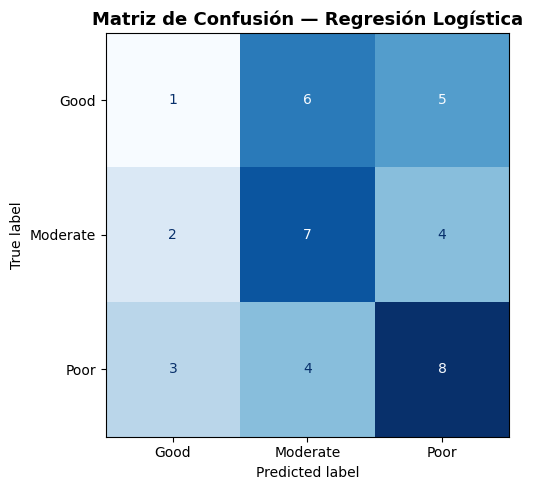

In [ ]:
# ── 5. Matriz de Confusión ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
cm      = confusion_matrix(y_test, y_pred, labels=modelo_lr.classes_)
disp    = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo_lr.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de Confusión — Regresión Logística', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Curva ROC

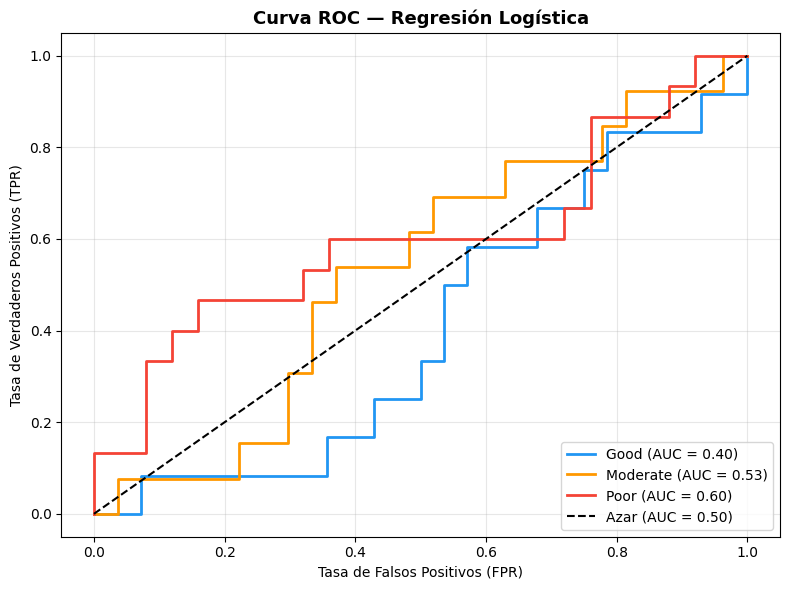

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Binarizar las clases para ROC multiclase ───────────────────
clases    = ['Good', 'Moderate', 'Poor']
y_test_bin = label_binarize(y_test, classes=clases)

# ── 2. Probabilidades predichas ───────────────────────────────────
y_prob = modelo_lr.predict_proba(X_test_scaled)

# ── 3. Calcular ROC y AUC por clase ───────────────────────────────
colores = ['#2196F3', '#FF9800', '#F44336']

fig, ax = plt.subplots(figsize=(8, 6))

for i, (clase, color) in enumerate(zip(clases, colores)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{clase} (AUC = {roc_auc:.2f})')

# ── 4. Línea de azar ──────────────────────────────────────────────
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Azar (AUC = 0.50)')

# ── 5. Formato ────────────────────────────────────────────────────
ax.set_title('Curva ROC — Regresión Logística', fontsize=13, fontweight='bold')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


El modelo alcanzó un **accuracy del 40%**, lo que indica que clasifica correctamente
4 de cada 10 pacientes en cuanto a su respuesta al tratamiento.

Analizando por clase, `Poor` y `Moderate` presentan un desempeño aceptable con
F1-scores de **0.50** y **0.47** respectivamente, mientras que `Good` resulta
ser la clase más difícil de predecir con apenas **0.11**, lo que sugiere que
el modelo tiene dificultades para distinguir a los pacientes con buena respuesta
al tratamiento.

La matriz de confusión confirma esto, ya que la mayoría de los casos `Good`
son clasificados erróneamente como `Moderate` o `Poor`, mientras que
`Poor` y `Moderate` muestran una concentración mayor en la diagonal principal,
indicando mejores aciertos en esas clases.

Por ultimo, la curva ROC para cada clase de salida nos muestra que el modelo de Regresión logistica es malisimo para predecir si a los pacientes con buena respuesta al tratamiento, con un 0.4, estamos abajo del azar, lo cual nos indica que el modelo no es bueno.

# Modelo LDA
## Linear Discriminant Analysis (LDA)

LDA es un método de clasificación que busca encontrar una combinación lineal
de features que **maximice la separación entre clases** y **minimice la
varianza dentro de cada clase**. A diferencia de la Regresión Logística,
LDA asume que los datos siguen una **distribución normal** y que todas las
clases comparten la **misma matriz de covarianza**.


### Distribución de datos

Cuando hablamos de LDA, asumimos que los datos tienen una distribucion normal, con el fin de verlo graficamente, hagamos una grafica de la distribución de estas clases y un scatter de la misma para ver que tan bien estan separados los datos.

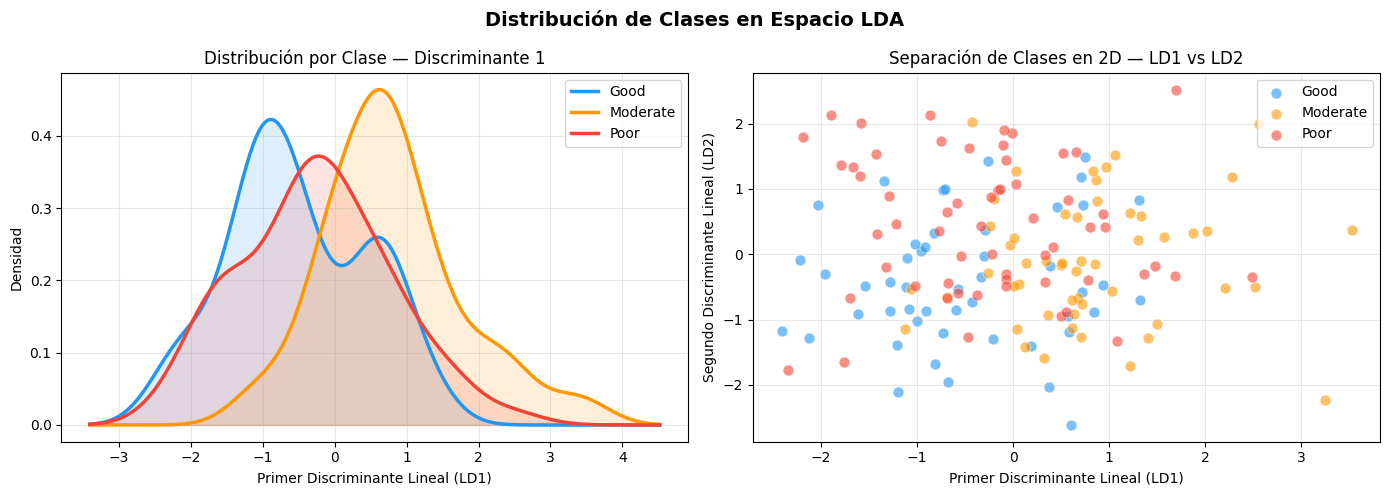

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# ── Proyectar los datos al espacio LDA ────────────────────────────
X_train_lda = modelo_lda.transform(X_train_scaled)

clases  = ['Good', 'Moderate', 'Poor']
colores = ['#2196F3', '#FF9800', '#F44336']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de Clases en Espacio LDA', fontsize=14, fontweight='bold')

# ── Gráfica 1: Distribución 1D por cada clase (las campanas) ──────
ax = axes[0]
for clase, color in zip(clases, colores):
    # Filtrar datos de esta clase
    datos = X_train_lda[y_train == clase, 0]

    # Estimar la densidad (KDE) para suavizar la campana
    kde  = gaussian_kde(datos, bw_method=0.4)
    x    = np.linspace(X_train_lda[:, 0].min() - 1,
                       X_train_lda[:, 0].max() + 1, 300)

    ax.plot(x, kde(x), color=color, lw=2.5, label=clase)
    ax.fill_between(x, kde(x), alpha=0.15, color=color)

ax.set_title('Distribución por Clase — Discriminante 1', fontsize=12)
ax.set_xlabel('Primer Discriminante Lineal (LD1)')
ax.set_ylabel('Densidad')
ax.legend()
ax.grid(alpha=0.3)

# ── Gráfica 2: Scatter 2D en espacio LDA ──────────────────────────
ax = axes[1]
for clase, color in zip(clases, colores):
    mask = y_train == clase
    ax.scatter(X_train_lda[mask, 0], X_train_lda[mask, 1],
               color=color, label=clase, alpha=0.6, edgecolors='white',
               linewidth=0.5, s=60)

ax.set_title('Separación de Clases en 2D — LD1 vs LD2', fontsize=12)
ax.set_xlabel('Primer Discriminante Lineal (LD1)')
ax.set_ylabel('Segundo Discriminante Lineal (LD2)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Como podemos darnos cuenta, las clases estan muy mezcladas, por lo que eso nos podria decir que sera algo dificil(no imposible) encontrar un buen modelo que pueda predecir correctamente.

Crear modelo

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
# ── 1. Modelo LDA ─────────────────────────────────────────────────
modelo_lda = LinearDiscriminantAnalysis()
modelo_lda.fit(X_train_scaled, y_train)

LinearDiscriminantAnalysis()

Predicciones y metricas

In [ ]:
# ── 2. Predicciones ────────────────────────────────────────────────
y_pred_lda = modelo_lda.predict(X_test_scaled)

# ── 3. Métricas ────────────────────────────────────────────────────
accuracy_lda = accuracy_score(y_test, y_pred_lda)
print(f"✅ Accuracy: {accuracy_lda*100:.2f}%\n")
print("📋 Reporte de Clasificación:")
print(classification_report(y_test, y_pred_lda))

✅ Accuracy: 45.00%

📋 Reporte de Clasificación:
              precision    recall  f1-score   support

        Good       0.20      0.08      0.12        12
    Moderate       0.47      0.69      0.56        13
        Poor       0.50      0.53      0.52        15

    accuracy                           0.45        40
   macro avg       0.39      0.44      0.40        40
weighted avg       0.40      0.45      0.41        40



Bueno, mejoro un 5% mas que el modelo de regresión logistica, pero sigue sin ser muy bueno que digamos. Parece que solo podemos predecir de forma global el 45% de los datos de nuestro dataset, ahora veamos la matriz de confusión para ver que esta pasando, ya que vemos que la respuesta al tratamiento `Good`, sigue siendo muy mala.

Matriz de Confusión

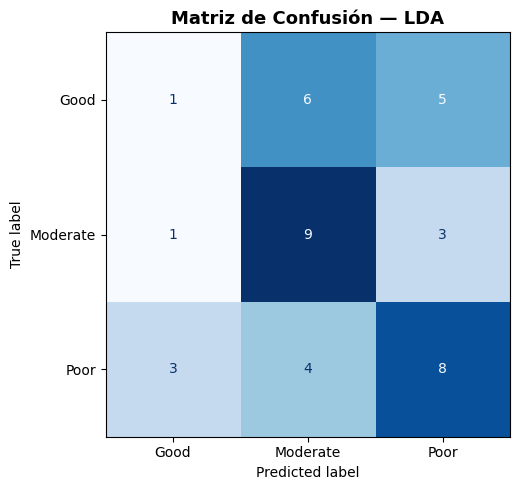

In [ ]:
# ── 4. Matriz de Confusión ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
cm   = confusion_matrix(y_test, y_pred_lda, labels=modelo_lda.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo_lda.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de Confusión — LDA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

La respuesta `Good`, sigue siendo la mas dificil de predecir, con solo 1 predicción correcta, sin embargo parece que ahora podemos predecir mejor las respuestas moderadas y pobres, lo cual es un avance.

Curva ROC

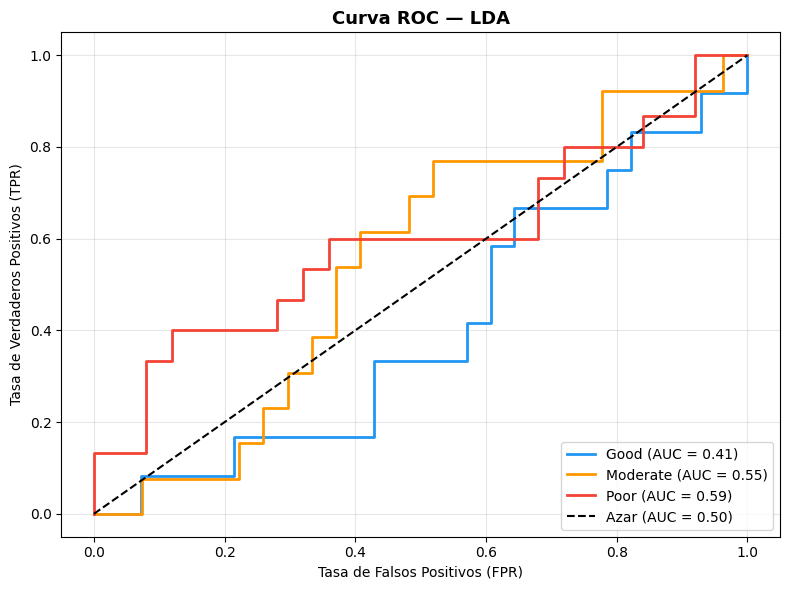

In [ ]:
# ── 5. Curva ROC ───────────────────────────────────────────────────
clases     = ['Good', 'Moderate', 'Poor']
y_test_bin = label_binarize(y_test, classes=clases)
y_prob_lda = modelo_lda.predict_proba(X_test_scaled)
colores    = ['#2196F3', '#FF9800', '#F44336']

fig, ax = plt.subplots(figsize=(8, 6))
for i, (clase, color) in enumerate(zip(clases, colores)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_lda[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{clase} (AUC = {roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Azar (AUC = 0.50)')
ax.set_title('Curva ROC — LDA', fontsize=13, fontweight='bold')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Como se esperaba, las respuestas `Good`, estan practicamente abajo del azar, pero, podemos notar que las demas respuestas mejoraron en su calidad de predicción.

LDA mostró una ligera mejora respecto a la Regresión Logística, alcanzando un
accuracy levemente superior. La clase `Moderate` mejoró notablemente, con 9 de
13 casos clasificados correctamente, mientras que `Poor` mantiene un desempeño
aceptable con 8 aciertos de 15.

`Good` sigue siendo la clase más difícil de predecir, con solo 1 acierto de 12,
siendo confundida principalmente con `Moderate` y `Poor`.

La curva ROC refleja este comportamiento, con AUC de **0.59** para `Poor`,
**0.55** para `Moderate` y **0.41** para `Good`, todos cercanos al azar,
lo que confirma la dificultad del modelo para separar las clases de forma confiable.

# Modelos de ensamble

## Gradient Boosting

El Boosting es un método de ensamble que construye modelos de forma **secuencial**,
donde cada modelo nuevo se enfoca en corregir los errores del anterior.
A diferencia de Random Forest que construye árboles en paralelo e independientes,
Boosting los construye uno a uno, **aprendiendo de sus errores iterativamente**.

En cada iteración, las observaciones mal clasificadas reciben **mayor peso**,
forzando al siguiente modelo a prestarles más atención:

$$F_m(x) = F_{m-1}(x) + \lambda \cdot h_m(x)$$

Donde $F_{m-1}$ es el modelo anterior, $h_m$ es el nuevo árbol correctivo
y $\lambda$ es la **tasa de aprendizaje** que controla cuánto corrige cada árbol.

Crear modelo

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ── 1. Modelo Gradient Boosting ───────────────────────────────────
modelo_gb = GradientBoostingClassifier(
    n_estimators  = 100,   # Número de árboles
    learning_rate = 0.1,   # Tasa de aprendizaje
    max_depth     = 3,     # Profundidad de cada árbol
    random_state  = 42
)

modelo_gb.fit(X_train_scaled, y_train)

GradientBoostingClassifier(random_state=42)

Predicciones y Metricas

In [ ]:
# ── 2. Predicciones ────────────────────────────────────────────────
y_pred_gb = modelo_gb.predict(X_test_scaled)

# ── 3. Métricas ────────────────────────────────────────────────────
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f"✅ Accuracy: {accuracy_gb*100:.2f}%\n")
print("📋 Reporte de Clasificación:")
print(classification_report(y_test, y_pred_gb))

✅ Accuracy: 42.50%

📋 Reporte de Clasificación:
              precision    recall  f1-score   support

        Good       0.31      0.33      0.32        12
    Moderate       0.50      0.38      0.43        13
        Poor       0.47      0.53      0.50        15

    accuracy                           0.42        40
   macro avg       0.43      0.42      0.42        40
weighted avg       0.43      0.42      0.42        40



Como vemos, obtuvimos resultados peores que el anterior pero un poco mejores que la regresión logistica, pudiendo predecir de forma global solo el 42.5% de los datos del conjunto. De nuevo, las predicciones de `Good`, siguen siendo las que mas traen problemas al modelo.

Matriz de confusión

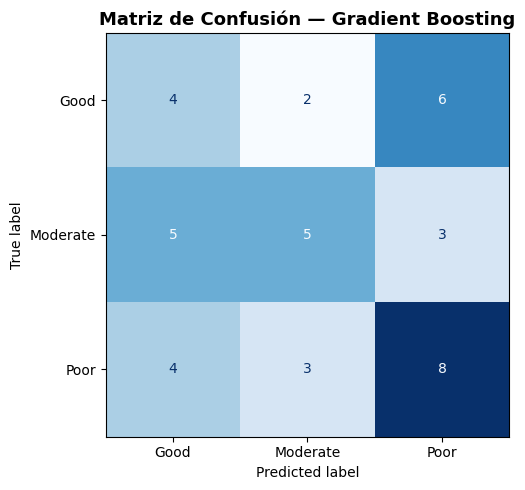

In [ ]:
# ── 4. Matriz de Confusión ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
cm   = confusion_matrix(y_test, y_pred_gb, labels=modelo_gb.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo_gb.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de Confusión — Gradient Boosting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Ahora, al parecer, las respuestas que mejor puede predecir son las `poor`, Seguido de las `moderate` y luego las `good`.

Curva ROC

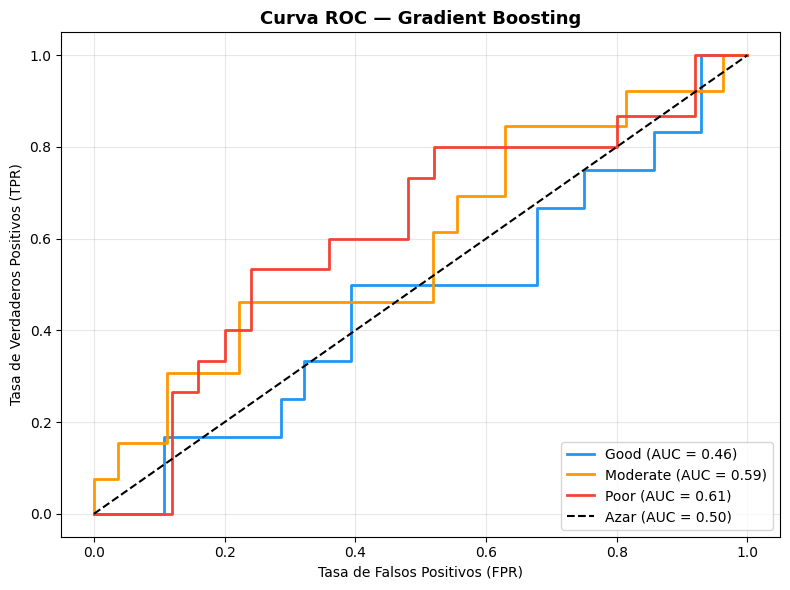

In [ ]:
# ── 5. Curva ROC ───────────────────────────────────────────────────
clases     = ['Good', 'Moderate', 'Poor']
y_test_bin = label_binarize(y_test, classes=clases)
y_prob_gb  = modelo_gb.predict_proba(X_test_scaled)
colores    = ['#2196F3', '#FF9800', '#F44336']

fig, ax = plt.subplots(figsize=(8, 6))
for i, (clase, color) in enumerate(zip(clases, colores)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_gb[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{clase} (AUC = {roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Azar (AUC = 0.50)')
ax.set_title('Curva ROC — Gradient Boosting', fontsize=13, fontweight='bold')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Gradient Boosting mostró una mejora general en los AUC respecto a los modelos
anteriores, siendo el primer modelo en superar **0.46** para la clase `Good`.
`Poor` mantiene el mejor desempeño con 8 aciertos y un AUC de **0.61**,
mientras que `Good` mejora notablemente respecto a modelos anteriores
con 4 aciertos de 12.

Sin embargo, `Moderate` retrocede ligeramente con solo 5 aciertos de 13,
siendo confundida principalmente con `Good`. En general, Gradient Boosting
presenta los **mejores AUC globales** de los tres modelos evaluados hasta ahora,
sugiriendo que captura mejor la estructura no lineal de los datos.

Importancia de variables

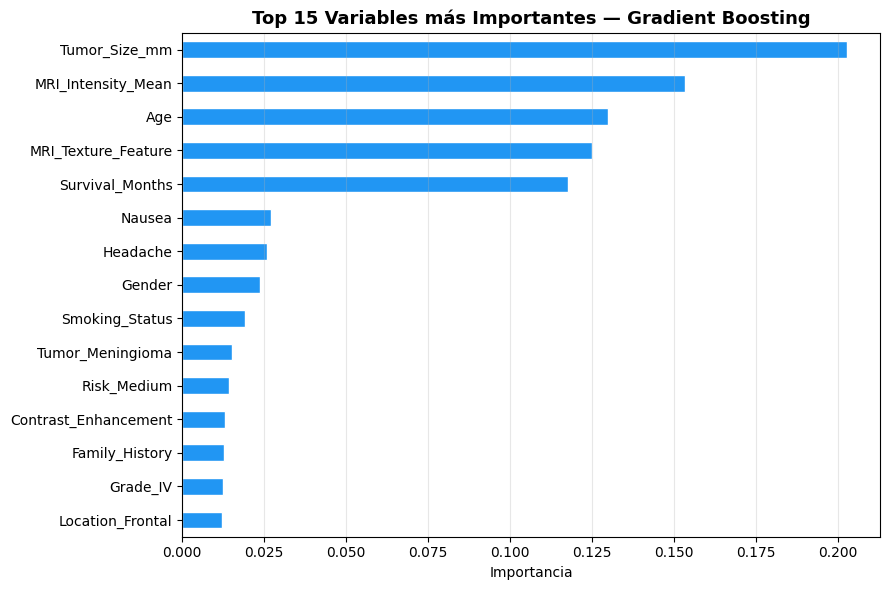

In [ ]:
# ── 6. Feature Importance ─────────────────────────────────────────
importancias = pd.Series(modelo_gb.feature_importances_,
                         index=X_train.columns).sort_values(ascending=False)[:15]

fig, ax = plt.subplots(figsize=(9, 6))
importancias.plot(kind='barh', ax=ax, color='#2196F3', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 15 Variables más Importantes — Gradient Boosting',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

Al parecer las variables mas importantes en este dataset, para el modelo de gradient boosting, es el tamaño del tumor en mm seguido de la intensidad de la resonancia magnetica promedio, la edad, entre otros, cosa que nos puede ser de utilidad para tomar desiciones en otro tipo de modelo.

# Support Vector Machines

SVM es un modelo que busca encontrar el **hiperplano óptimo** que separa
las clases maximizando el **margen** entre ellas. Los puntos más cercanos
al hiperplano se denominan **vectores de soporte** y son los únicos que
definen la frontera de decisión.

Para problemas no linealmente separables, SVM utiliza el **kernel trick**,
que transforma los datos a un espacio dimensional superior donde sí son
separables:

$$f(x) = \sum_{i=1}^{n} \alpha_i y_i K(x_i, x) + b$$

Donde $K(x_i, x)$ es la **función kernel** que mide la similitud entre
puntos, y $\alpha_i$ son los pesos de los vectores de soporte.

Crear modelo

In [ ]:
from sklearn.svm import SVC

# ── 1. Modelo SVM ─────────────────────────────────────────────────
modelo_svm = SVC(
    kernel      = 'rbf',    # Kernel Radial Basis Function
    C           = 1.0,      # Penalización por error
    gamma       = 'scale',  # Coeficiente del kernel
    probability = True,     # Necesario para curva ROC
    random_state= 42
)

modelo_svm.fit(X_train_scaled, y_train)

SVC(probability=True, random_state=42)

Predicciones y metricas

In [ ]:
# ── 2. Predicciones ────────────────────────────────────────────────
y_pred_svm = modelo_svm.predict(X_test_scaled)

# ── 3. Métricas ────────────────────────────────────────────────────
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"✅ Accuracy: {accuracy_svm*100:.2f}%\n")
print("📋 Reporte de Clasificación:")
print(classification_report(y_test, y_pred_svm))

✅ Accuracy: 37.50%

📋 Reporte de Clasificación:
              precision    recall  f1-score   support

        Good       0.00      0.00      0.00        12
    Moderate       0.38      0.38      0.38        13
        Poor       0.42      0.67      0.51        15

    accuracy                           0.38        40
   macro avg       0.27      0.35      0.30        40
weighted avg       0.28      0.38      0.32        40



Wow, si que es malisimo, es el mas bajo que hemos obtenido hasta ahora, con un poder global predictivo de 37.5%, notese como la respuesta `Good`, no fue predicha correctamente en ningun caso.

Matriz de confusión

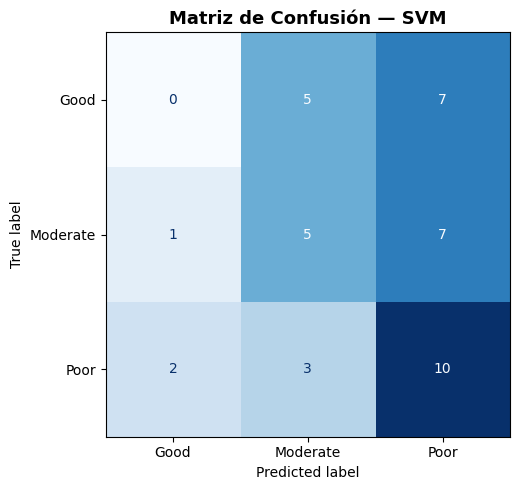

In [ ]:
# ── 4. Matriz de Confusión ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
cm   = confusion_matrix(y_test, y_pred_svm, labels=modelo_svm.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo_svm.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de Confusión — SVM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Lo que confirmabamos, al parecer no es capaz de predecir ningun buen tratamiento, pero si

Curva ROC

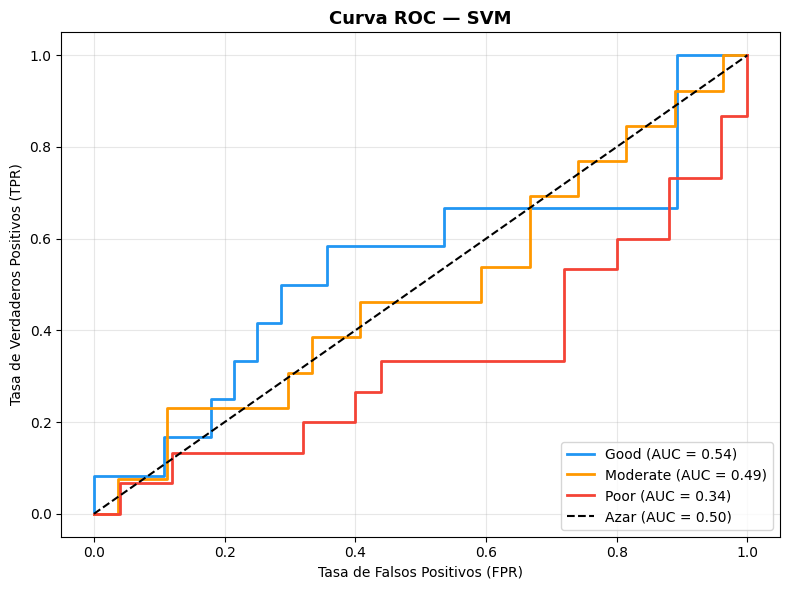

In [ ]:
# ── 5. Curva ROC ───────────────────────────────────────────────────
y_prob_svm = modelo_svm.predict_proba(X_test_scaled)
clases     = ['Good', 'Moderate', 'Poor']
y_test_bin = label_binarize(y_test, classes=clases)
colores    = ['#2196F3', '#FF9800', '#F44336']

fig, ax = plt.subplots(figsize=(8, 6))
for i, (clase, color) in enumerate(zip(clases, colores)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_svm[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{clase} (AUC = {roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Azar (AUC = 0.50)')
ax.set_title('Curva ROC — SVM', fontsize=13, fontweight='bold')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

SVM mostró hasta ahora el peor desempeño de todos los modelos evaluados, con un accuracy
de **37.50%**, por debajo incluso del azar. La clase `Good` no tuvo ningún
acierto con F1 de **0.00**, siendo clasificada completamente como `Moderate`
o `Poor`. `Poor` fue la única clase con un desempeño aceptable gracias a su
recall de **0.67**, aunque a costa de clasificar erróneamente muchos casos
de otras clases como `Poor`.

La curva ROC confirma este comportamiento invertido, donde `Poor` obtiene
un AUC de apenas **0.34**, por debajo del azar, mientras que curiosamente
`Good` alcanza **0.54**, el mejor AUC de las tres clases a pesar de no
tener ningún acierto directo.

Parece que nuestra ultima esperanza es el modelo de Redes Neuronales

# Modelo de Redes Neuronales

Una red neuronal artificial está inspirada en el funcionamiento del cerebro humano.
Se compone de **capas de neuronas** interconectadas donde cada neurona recibe
entradas, las pondera con **pesos** $w$ y aplica una **función de activación**
para producir una salida:

$$a = f\left(\sum_{i=1}^{n} w_i x_i + b\right)$$

El aprendizaje ocurre mediante **backpropagation**, que ajusta los pesos
iterativamente minimizando el error entre la predicción y el valor real.
Utilizaremos la función de activación **ReLU** en las capas ocultas y
**Softmax** en la capa de salida para obtener probabilidades por clase.

📋 Codificación de clases:
   Good → 0
   Moderate → 1
   Poor → 2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,739 (18.51 KB)

 Trainable params: 4,739 (18.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 142ms/step - accuracy: 0.3438 - loss: 1.1491 - val_accuracy: 0.4375 - val_loss: 1.1512
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4453 - loss: 1.0904 - val_accuracy: 0.3750 - val_loss: 1.1550
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.4922 - loss: 1.0464 - val_accuracy: 0.3438 - val_loss: 1.1602
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5234 - loss: 1.0085 - val_accuracy: 0.3438 - val_loss: 1.1630
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5625 - loss: 0.9759 - val_accuracy: 0.3438 - val_loss: 1.1646
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6250 - loss: 0.9448 - val_accuracy: 0.3125 - val_loss: 1.1653
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6562 - loss: 0.9134 - val_accuracy: 0.3125 - val_loss: 1.1663
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6875 - loss: 0.8835 - val_accuracy: 0.2812 - val_loss

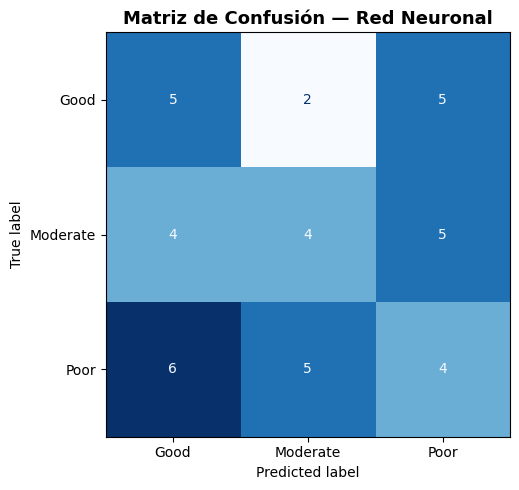

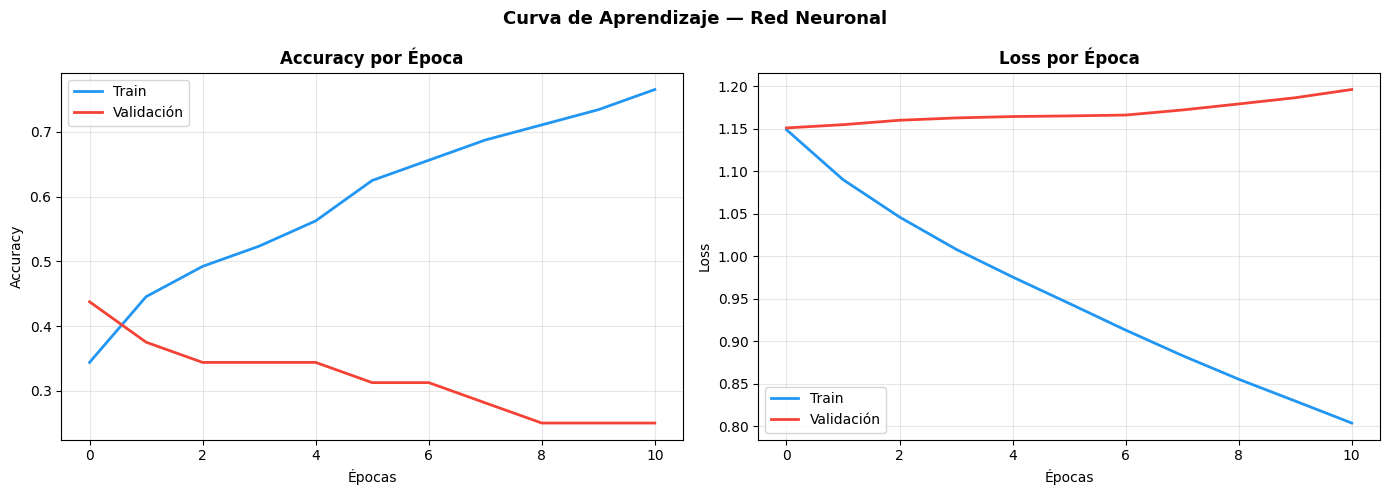

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


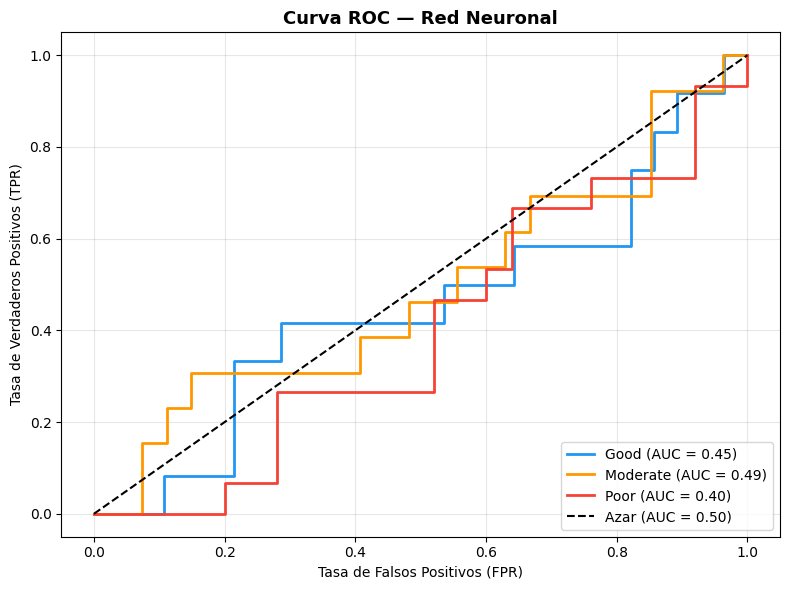

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# ── 1. Codificar el target a numérico (requerido por Keras) ────────
le            = LabelEncoder()
y_train_enc   = le.fit_transform(y_train)
y_test_enc    = le.transform(y_test)

print(f"📋 Codificación de clases:")
for i, clase in enumerate(le.classes_):
    print(f"   {clase} → {i}")

# ── 2. Construcción de la red neuronal ────────────────────────────
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(3,  activation='softmax'))  # 3 clases: Good, Moderate, Poor

model.summary()

# ── 3. Configurar fase de entrenamiento ───────────────────────────
opt = Adam(learning_rate=0.001)

model.compile(
    optimizer = opt,
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

# ── 4. Early Stopping ─────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor             = 'val_accuracy',
    patience            = 10,
    restore_best_weights= True
)

# ── 5. Entrenar el modelo ─────────────────────────────────────────
history = model.fit(
    X_train_scaled, y_train_enc,
    epochs           = 100,
    validation_split = 0.2,
    batch_size       = 32,
    callbacks        = [early_stop],
    verbose          = 1
)

# ── 6. Evaluación ─────────────────────────────────────────────────
y_pred_enc = model.predict(X_test_scaled).argmax(axis=1)
y_pred_nn  = le.inverse_transform(y_pred_enc)

accuracy_nn = accuracy_score(y_test, y_pred_nn)
print(f"\n✅ Accuracy: {accuracy_nn*100:.2f}%\n")
print("📋 Reporte de Clasificación:")
print(classification_report(y_test, y_pred_nn))

# ── 7. Matriz de Confusión ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
cm   = confusion_matrix(y_test, y_pred_nn, labels=le.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de Confusión — Red Neuronal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 8. Curva de Aprendizaje ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     color='#2196F3', lw=2, label='Train')
axes[0].plot(history.history['val_accuracy'], color='#F44336', lw=2, label='Validación')
axes[0].set_title('Accuracy por Época', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],     color='#2196F3', lw=2, label='Train')
axes[1].plot(history.history['val_loss'], color='#F44336', lw=2, label='Validación')
axes[1].set_title('Loss por Época', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Curva de Aprendizaje — Red Neuronal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 9. Curva ROC ───────────────────────────────────────────────────
y_prob_nn  = model.predict(X_test_scaled)
clases     = ['Good', 'Moderate', 'Poor']
y_test_bin = label_binarize(y_test, classes=clases)
colores    = ['#2196F3', '#FF9800', '#F44336']

fig, ax = plt.subplots(figsize=(8, 6))
for i, (clase, color) in enumerate(zip(clases, colores)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_nn[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{clase} (AUC = {roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Azar (AUC = 0.50)')
ax.set_title('Curva ROC — Red Neuronal', fontsize=13, fontweight='bold')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Vaya, este modelo es pesimo, en toda la extension de la palabra, con un poder predictivo de 32.5 % global, donde todas las predicciones son producto del azar segun el modelo.

Redes neuronales, finalmente mostró hasta ahora el peor desempeño de todos los modelos evaluados, con un accuracy de **32.50%**, por debajo incluso del azar. La clase `Good`cacierto con F1 de **0.37**, siendo clasificada mas veces como `poor`.

La curva ROC nos dice que la peor curva de desempeño es la de `poor`, con un AUC de **0.40**, siendo peor que el azar.

Asi mismo vemos que tenemos una diferencia exagerada en la validacion del train y test de las curvas de accuracy y loss por epoca, lo cual sugiere problemas y muy grandes.

# Selección Final del modelo

# Comparativa

| Modelo                          | Accuracy (%) |
|---------------------------------|-------------|
| Linear Discriminant Analysis    | 45.00       |
| Gradient Boosting               | 42.50       |
| Logistic Regression             | 40.00       |
| Support Vector Machine (SVM)    | 37.50       |
| Red Neuronal (Keras/TensorFlow) | 32.50       |

En terminos de accuracy, el modelo con mejor desempeño, es LDA con un accuracy de **45%**, al contrario de lo que no podria pensar, una complejidad mas alta en el modelo no significa un mejor desempeño, si no al contrario, parece que a mas alta complejidad, peor desempeño en este caso.



# Conclusiones

En general lo que aprendimos de este analisis sobre la clasificación y predicción de respuesta al tratamiento de pacientes con tumores cerebrales, es que, al ser un tema relacionado a la salud, debemos ser muy criticos con lo que estamos haciendo ya que impacta mucho en las personas.

El modelo mas adecuado o aceptable seria el LDA, en terminos de accuracy, sin embargo, por su bajo porcentaje, bajo ninguna circunstancia, se motiva a usar este modelo, debido a su falta de desempeño.

Las limitaciones del estudio, posiblemente sea la base de datos en si misma, ya que al ser provenientes de kaggle, puede que los datos no se hayan trabajado correctamente o inclusive que hayan sido generados.

Una de las mejoras que se podrian hacer es que se podria buscar una base de datos mas real, con posibles huecos, outliers, valores atipicos reales, esto para trabajarlos de forma correcta con el contexto real.


Muchas gracias por tomarte el tiempo de leer este proyecto!

